In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import sys
import numpy as np
from scipy.stats import gaussian_kde

In [2]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
pd.set_option('display.float_format', '{:.3f}'.format)

In [3]:
def saturation_func(df):
    x = df["flexibility_MWh"]
    y = df["updated_max_flexibility_MWh"]
    a = df["shaping_parameters"][0]
    b = df["shaping_parameters"][1]

    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
        
    z_positive = max(z, 0)
    return round(z_positive, 3)

In [4]:
def calculate_revenue(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    df["actual_flexibility_cost_DKK"] = df.apply(saturation_func, axis=1)
    return df

def results_summary(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    solve_check = 100 * round(optimization_results.mip_gap, 3) <= 1.0
    
    summary_dict = {"objective_value": df.net_revenue.sum(), 
                    "mean_square_error": df.square_error.mean(),
                    "runtime": optimization_results.runtime, 
                    "cpu_time": optimization_results.cpu_time, 
                    "mip_gap": 100 * round(optimization_results.mip_gap, 3), 
                    "solve_check": solve_check}
    return [pd.DataFrame(summary_dict, index=[0]), df[["actual_flexibility_cost_DKK", "flexibility_cost_DKK"]]]

In [5]:
results_path = os.path.join(cwd, "price scenario results")
folders = ["PWL", "Gurobi ML", "Proposed", "FICNN"]
summary_cols = ["objective_value", "mean_square_error", "runtime", 
                "cpu_time", "mip_gap", "solve_check", "methodology", "scenario_type", "case"]

In [6]:
summary_dict = {}
index = 0
for folder in list(folders):
    filepath = os.path.join(results_path, folder)
    if folder == "Proposed":
        folder_name = "NWLP"
    else:
        folder_name = folder
    for filename in list(os.listdir(filepath))[0: 1]:
        file_path = os.path.join(filepath, filename)
        summary_dict[folder_name] = read_pickle(os.path.join(filepath, "Results_with_revenue.pickle"))

In [7]:
results_path = os.path.join(cwd, "penalty sensitivity results")
folders = ["PCAR", "PCTAR"]
summary_cols = ["objective_value", "mean_square_error", "runtime", 
                "cpu_time", "mip_gap", "solve_check", "methodology", "scenario_type", "case"]

In [8]:
best_cases_df = read_pickle("best_cases_df.pickle")

In [9]:
best_cases_df

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,methodology,scenario_type,case,weights,alpha
0,14226.267,1111.447,0.026,0.031,0,True,PCAR,High_prices,0,"(2, 1)",1
1,41802.004,867.967,0.030,0.062,0,True,PCAR,High_prices,1,"(1, 0)",1
2,20158.502,1237.987,0.023,0.031,0,True,PCAR,High_prices,2,"(2, -1)",1
3,59050.844,14143.206,0.022,0.031,0,True,PCAR,High_prices,3,"(10, -1)",1
4,57450.104,3016.711,0.030,0.078,0,True,PCAR,High_prices,4,"(5, 1)",1
5,67233.744,13826.415,0.030,0.062,0,True,PCAR,High_prices,5,"(2, -1)",1
6,60009.070,14143.206,0.022,0.016,0,True,PCAR,High_prices,6,"(2, -1)",1
7,46956.695,14143.206,0.030,0.031,0,True,PCAR,High_prices,7,"(1, 0)",1
8,108883.419,14143.206,0.028,0.047,0,True,PCAR,High_prices,8,"(2, -1)",1
9,32841.932,3070.089,0.023,0.031,0,True,PCAR,High_prices,9,"(2, -1)",1


In [10]:
index = 0
for folder in list(folders):
    filepath = os.path.join(results_path, folder)
    if folder == "Proposed":
        folder_name = "NWLP"
    else:
        folder_name = folder
    summary_dict[folder_name] = {}
    for filename in list(os.listdir(filepath))[0: 1]:
        file_path = os.path.join(filepath, filename)
        data = read_pickle(os.path.join(filepath, "Results_with_revenue.pickle"))
        for scenario, scenario_dict in data.items():
            summary_dict[folder_name][scenario] = {}
            for instance, instance_dict in scenario_dict.items():
                cond1 = best_cases_df.methodology == folder_name
                cond2 = best_cases_df.case == instance
                cond3 = best_cases_df.scenario_type == scenario
                weight = best_cases_df[cond1 & cond2 & cond3].weights.values
                # print(weight)
                # print(instance_dict[weight[0]])
                summary_dict[folder_name][scenario][instance] = instance_dict[weight[0]][1]
            

In [11]:
summary_dict["PCAR"]["Low_prices"]["1"]

Optimization_Results(decision_variables=    flexibility_MWh  updated_max_flexibility_MWh  flexibility_cost_DKK  \
0             9.963                       13.327               193.696   
1             9.618                        9.618               145.975   
2             8.811                        8.811               169.635   
3             7.025                        7.025               138.509   
4             7.346                        7.346               135.833   
5             4.871                        4.871               134.058   
6             3.104                        3.104               119.664   
7             2.541                        2.541               114.585   
8             1.985                        1.985               121.572   
9             0.561                        0.561               126.940   
10            1.331                        1.331               104.592   
11            0.342                        0.342               114.417  

KeyError: ''

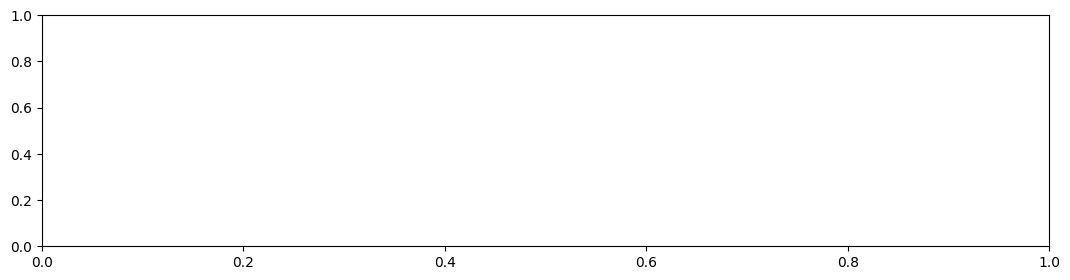

In [12]:
scenario_type = "Low_prices"
legend_pos = ["upper center"] * 3 + ["upper right"]* 2
for i, folder in enumerate(["", "PCAR", "PCTAR"]):
    folder_name = "NWLP" if folder == "Proposed" else folder
    for j in range(5, 6):
        fig, ax1 = plt.subplots(figsize=(13, 3))

        # Bar plot
        df = summary_dict[folder_name][scenario_type][str(j)].decision_variables[
            ["updated_max_flexibility_MWh", "flexibility_MWh"]].copy()
        
        # Calculate unused capacity
        df["unused_flexibility"] = df["updated_max_flexibility_MWh"] - df["flexibility_MWh"]
        
        # Plot stacked bar: unused below, used on top
        ax1 = df[["flexibility_MWh", "unused_flexibility"]].plot(
            kind="bar",
            stacked=True,
            ax=ax1,
            color=["xkcd:lavender", "xkcd:light gray"],
            edgecolor="black"
        )        # Line plot on secondary y-axis
        ax1.set_ylabel("Volume", fontsize=20)
        ax2 = ax1.twinx()
        ax2.set_ylabel(r"Price" + "\n" + "(log-scale)", fontsize=20)
        market_price = (summary_dict[folder_name][scenario_type][str(j)].decision_variables["market_price"]) 
                        #* summary_dict[folder_name][scenario_type][str(j)].decision_variables["flexibility_MWh"])
        market_price.plot(ax=ax2, color="xkcd:red", linestyle="--", marker="o", label="Market price (DKK/MWh)")
        cost_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["actual_flexibility_cost_DKK"]
        cost_price.plot(ax=ax2, color="xkcd:black", linestyle="--", marker="^", label="Actual cost of flexibility (DKK)" , 
                        linewidth=2, markersize=10)

        estimated_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["flexibility_cost_DKK"]
        estimated_price.plot(ax=ax2, color="xkcd:green", linestyle="--", marker="o", label="Estimated cost of flexibility (DKK)")
        # Legends
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, ["Flexibility reserved(MWh)", "Unused flexibility (MWh)"] + labels2, loc=legend_pos[i], ncols=2, fontsize=12)
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, fontsize=16)
        ax1.set_xticks([2 * i for i in range(13)])
        ax1.tick_params(axis='y', labelsize=16)
        ax2.tick_params(axis='y', labelsize=16)
        ax1.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)
        ax2.set_yscale('symlog', linthresh=0.1)
        ax2.set_ylim([-0.1, 1000])
        plt.tight_layout()
        # plt.savefig(folder_name + "_bid.pdf", bbox_inches="tight")
        plt.show()

In [ ]:
legend_handles_labels = None  # to store legend handles and labels once
scenario_type = "Low_prices"
for i, folder in enumerate(["PWL", "Gurobi ML", "Proposed", "PCAR", "PCTAR"]):
    folder_name = "NWLP" if folder == "Proposed" else folder
    for j in range(5, 6):
        fig, ax1 = plt.subplots(figsize=(10, 2))
        df = summary_dict[folder_name][scenario_type][str(j)].decision_variables[
            ["updated_max_flexibility_MWh", "flexibility_MWh"]].copy()
        df["unused_flexibility"] = df["updated_max_flexibility_MWh"] - df["flexibility_MWh"]
        
        # Bar plot
        ax1 = df[["flexibility_MWh", "unused_flexibility"]].plot(
            kind="bar", stacked=True, ax=ax1,
            color=["xkcd:lavender", "xkcd:light gray"],
            edgecolor="black"
        )
        ax1.set_ylabel("Volume", fontsize=20)

        ax2 = ax1.twinx()
        ax2.set_ylabel(r"Price" + "\n" + "(log-scale)", fontsize=20)

        market_price = (summary_dict[folder_name][scenario_type][str(j)].decision_variables["market_price"] 
                        * summary_dict[folder_name][scenario_type][str(j)].decision_variables["flexibility_MWh"])
        market_price.plot(ax=ax2, color="xkcd:red", linestyle="--", marker="o", label="mFRR capacity market revenue (DKK)", linewidth=2, markersize=10)
        cost_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["actual_flexibility_cost_DKK"]
        cost_price.plot(ax=ax2, color="xkcd:green", linestyle="--", marker="^", label="Actual up-regulation DSF cost (DKK)", linewidth=2, markersize=10)
        estimated_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["flexibility_cost_DKK"]
        estimated_price.plot(ax=ax2, color="xkcd:black", linestyle="--", marker="v", 
                             label="Estimated up-regulation DSF cost (DKK)", linewidth=2, markersize=10)

        # Collect handles only once
        if legend_handles_labels is None:
            handles1, labels1 = ax1.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            legend_handles_labels = (handles1 + handles2, ["Up-regulation DSF reserved (MWh)", "Unused up-regulation DSF (MWh)"] + labels2)

        # Remove legend from all plots
        ax1.legend().remove()
        ax2.legend().remove()

        # Plot setup
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, fontsize=16)
        ax1.set_xticks([2 * i for i in range(13)])
        ax1.tick_params(axis='y', labelsize=16)
        ax2.tick_params(axis='y', labelsize=16)
        ax1.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)
        ax2.set_yscale('symlog', linthresh=0.1)
        ax2.set_ylim([-0.1, 2000])

        plt.tight_layout()
        plt.savefig(folder_name + "_bid_v2.pdf", bbox_inches="tight")
        plt.show()

# Add standalone legend figure
fig_legend = plt.figure(figsize=(10, 1))
fig_legend.legend(*legend_handles_labels, loc='center', ncol=2, fontsize=20, frameon=False)
plt.axis('off')
plt.savefig("shared_legend.pdf", bbox_inches='tight')
plt.show()

NameError: name 'legend_handles_labels_new' is not defined

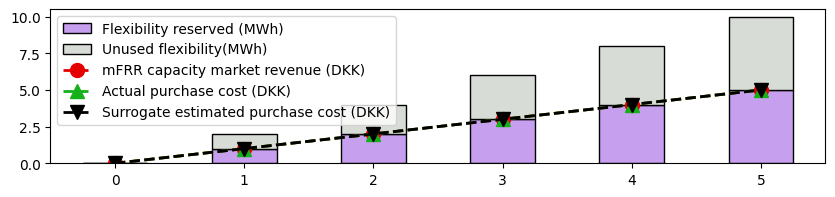

<Figure size 1000x100 with 0 Axes>

In [13]:
random_df = pd.DataFrame({
                          "Flexibility reserved (MWh)": [0, 1, 2, 3, 4, 5], 
                          "Unused flexibility(MWh)": [0, 1, 2, 3, 4, 5],
                          "mFRR capacity market revenue (DKK)": [0, 1, 2, 3, 4, 5], 
                          "Actual purchase cost (DKK)": [0, 1, 2, 3, 4, 5],
                          "Surrogate estimated purchase cost (DKK)": [0, 1, 2, 3, 4, 5]
                         })
cols = random_df.columns
fig, ax1 = plt.subplots(figsize=(10, 2))
ax1 = random_df[cols[0:2]].plot(
            kind="bar", stacked=True, ax=ax1,
            color=["xkcd:lavender", "xkcd:light gray"],
            edgecolor="black")
random_df[cols[2: 3]].plot(ax=ax1, color="xkcd:red", linestyle="--", marker="o", 
                           label="mFRR capacity market revenue (DKK)", linewidth=2, markersize=10)
random_df[cols[3: 4]].plot(ax=ax1, color="xkcd:green", linestyle="--", 
                          marker="^", label="Actual up-regulation DSF cost (DKK)", linewidth=2, markersize=10)
random_df[cols[4: 5]].plot(ax=ax1, color="xkcd:black", linestyle="--", marker="v", 
                             label="Estimated up-regulation DSF cost (DKK)", linewidth=2, markersize=10)
handles1, labels1 = ax1.get_legend_handles_labels()
legend_handles_labels = (handles1, labels1)
# Add standalone legend figure
fig_legend = plt.figure(figsize=(10, 1))
fig_legend.legend(*legend_handles_labels_new, loc='center', ncol=2, fontsize=20, frameon=False)
plt.axis('off')
plt.savefig("shared_legend_v2.pdf", bbox_inches='tight')
plt.show()

In [14]:
legend_handles_labels_new = ([handles1[x] for x in [-2, -1, 0, 1, 2]], [labels1[x] for x in [-2, -1, 0, 1, 2]])

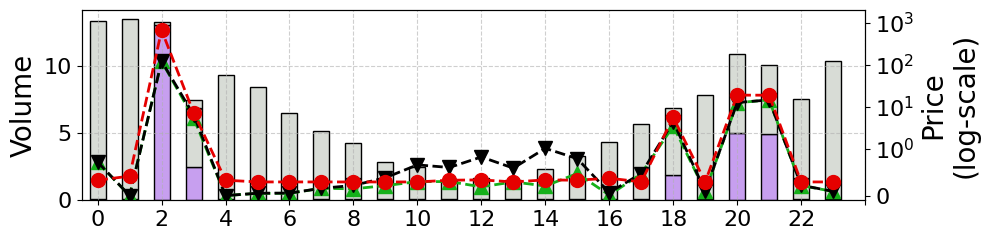

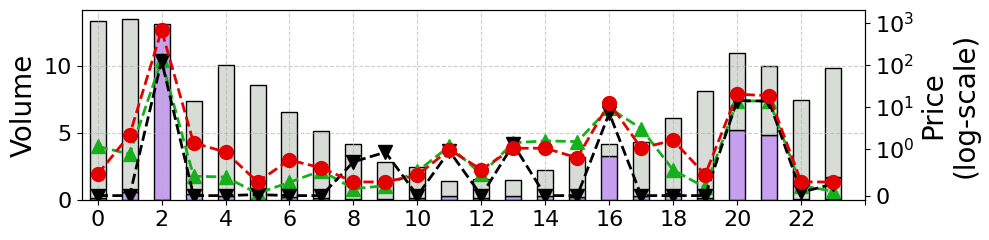

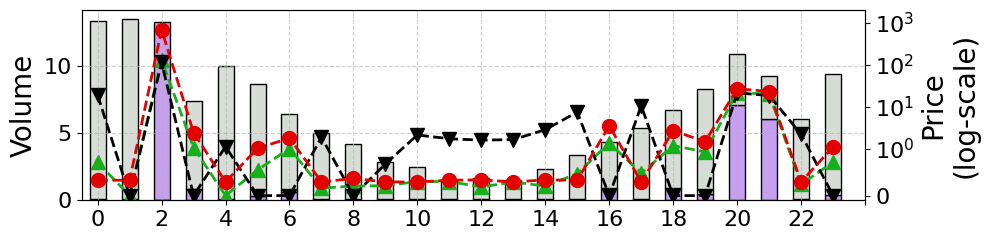

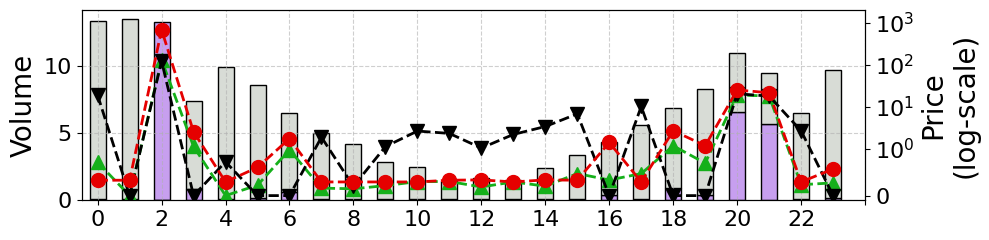

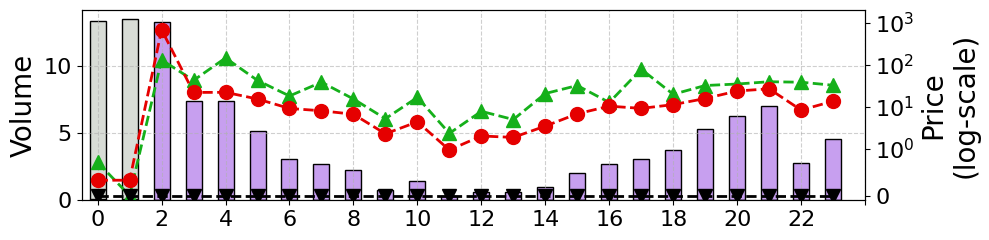

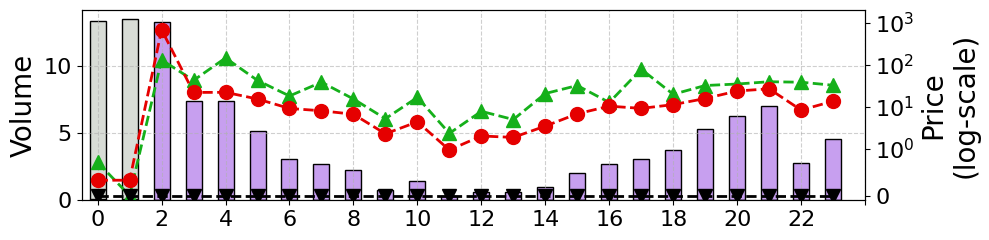

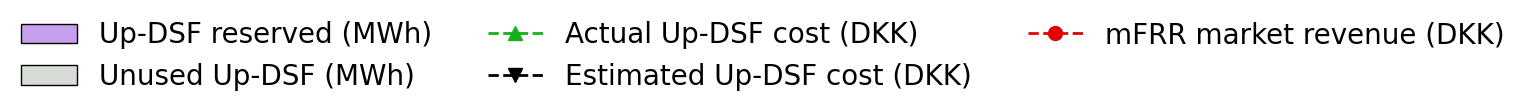

In [44]:
legend_handles_labels = None  # to store legend handles and labels once
scenario_type = "Low_prices"
for i, folder in enumerate(["PWL", "Gurobi ML", "Proposed", "FICNN", "PCAR", "PCTAR"]):
    folder_name = "NWLP" if folder == "Proposed" else folder
    for j in range(5, 6):
        fig, ax1 = plt.subplots(figsize=(10, 2.5))
        df = summary_dict[folder_name][scenario_type][str(j)].decision_variables[
            ["updated_max_flexibility_MWh", "flexibility_MWh"]].copy()
        df["unused_flexibility"] = df["updated_max_flexibility_MWh"] - df["flexibility_MWh"]
        
        # Bar plot
        ax1 = df[["flexibility_MWh", "unused_flexibility"]].plot(
            kind="bar", stacked=True, ax=ax1,
            color=["xkcd:lavender", "xkcd:light gray"],
            edgecolor="black"
        )
        ax1.set_ylabel("Volume", fontsize=20)

        ax2 = ax1.twinx()
        ax2.set_ylabel(r"Price" + "\n" + "(log-scale)", fontsize=20)

        market_price = (summary_dict[folder_name][scenario_type][str(j)].decision_variables["market_price"] 
                        * summary_dict[folder_name][scenario_type][str(j)].decision_variables["flexibility_MWh"])

        cost_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["actual_flexibility_cost_DKK"]
        cost_price.plot(ax=ax2, color="xkcd:green", linestyle="--", marker="^", label="Actual Up-DSF cost (DKK)", linewidth=2, markersize=10)
        estimated_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["flexibility_cost_DKK"]
        estimated_price.plot(ax=ax2, color="xkcd:black", linestyle="--", marker="v", 
                             label="Estimated Up-DSF cost (DKK)", linewidth=2, markersize=10)
        market_price.plot(ax=ax2, color="xkcd:red", linestyle="--", marker="o", label="mFRR market revenue (DKK)", linewidth=2, markersize=10)
        # Collect handles only once
        if legend_handles_labels is None:
            handles1, labels1 = ax1.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            legend_handles_labels = (handles1 + handles2, ["Up-DSF reserved (MWh)", "Unused Up-DSF (MWh)"] + labels2)

        # Remove legend from all plots
        ax1.legend().remove()
        ax2.legend().remove()

        # Plot setup
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, fontsize=16)
        ax1.set_xticks([2 * i for i in range(13)])
        ax1.tick_params(axis='y', labelsize=16)
        ax2.tick_params(axis='y', labelsize=16)
        ax1.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)
        ax2.set_yscale('symlog', linthresh=1)
        ax2.set_ylim([-0.1, 2000])

        plt.tight_layout()
        plt.savefig(folder_name + "_bid_v3.pdf", bbox_inches="tight")
        plt.show()

# Add standalone legend figure
fig_legend = plt.figure(figsize=(10, 1))
fig_legend.legend(*legend_handles_labels, loc='center', ncol=3, fontsize=20, frameon=False)
plt.axis('off')
plt.savefig("shared_legend.pdf", bbox_inches='tight')
plt.show()

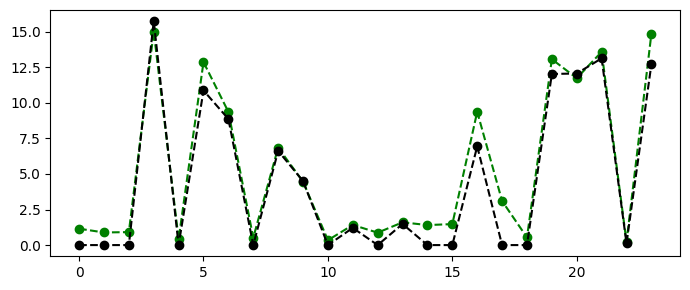

In [16]:
scenario_type = "High_prices"
legend_pos = ["upper right"] * 3 + ["upper center"]* 2
fig, ax1 = plt.subplots(figsize=(7, 3))
k = 9
for scenario_type in ["Low_prices"]:
    for i, folder in enumerate(["Gurobi ML"]):
        folder_name = "NWLP" if folder == "Proposed" else folder
        for j in range(k, k+1):
            # fig, ax1 = plt.subplots(figsize=(7, 3))
    
            # # Bar plot
            # data = summary_dict[folder_name][scenario_type][str(j)].decision_variables[
            #     ["updated_max_flexibility_MWh", "flexibility_MWh"]
            # ]
            # data.plot(kind="bar", ax=ax1, label=["Updated maximum flexibility", "Flexibility reserved"])
            # ax1.set_ylabel("Flexibility (MWh)")
    
            # Line plot on secondary y-axis
            # market_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["market_price"]
            # market_price.plot(ax=ax2, color="red", linestyle="--", marker="o", label="Market Price")
            # # ax2.set_ylabel("Market Price")
            cost_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["actual_flexibility_cost_DKK"]
            cost_price.plot(ax=ax1, color="green", linestyle="--", marker="o", label="Actual flexibility Price")

            estimated_price = summary_dict[folder_name][scenario_type][str(j)].decision_variables["flexibility_cost_DKK"]  
            estimated_price.plot(ax=ax1, color="xkcd:black", linestyle="--", marker="o", label="Estimated flexibility Price")
            # Legends
            # ax1.legend(handles1 + handles2, ["Updated maximum flexibility", "Flexibility reserved"] + handles2, loc=legend_pos[i], ncols=1)     
            plt.tight_layout()
plt.show()